In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from datasets import load_dataset

# load data
ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

# clean data
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

## Scatter plot for salary and skill demand correlation

1 - Prepare data

In [69]:
# filter for data analysts in the US
df_da_us = df.loc[
    (df["job_title_short"].str.contains("Data Analyst")) & (df["salary_year_avg"].notna()) & (df["job_country"] == "United States"),
    ["job_skills", "salary_year_avg"]
].copy()
df_da_us

,job_skills,salary_year_avg
109,"[python, r, alteryx, tableau]",89000.0
180,"[excel, powerpoint]",90250.0
410,"[sql, word, excel, visio, powerpoint, sharepoint]",133285.0
982,"[sas, sas]",85000.0
988,"[sql, excel, tableau]",62623.0
...,...,...
782798,[terminal],111175.0
783588,"[sql, r, python, hadoop, excel]",125000.0
783866,[unix],115000.0
784812,[sql],170000.0


In [70]:
# explode the skills column
exploded_df = df_da_us.explode("job_skills")
exploded_df

,job_skills,salary_year_avg
109,python,89000.0
109,r,89000.0
109,alteryx,89000.0
109,tableau,89000.0
180,excel,90250.0
...,...,...
784882,sql,87500.0
784882,vba,87500.0
784882,tableau,87500.0
784882,excel,87500.0


In [71]:
# aggregate the data
aggregated_df = exploded_df.groupby("job_skills").agg(
    median_salary=("salary_year_avg", "median"),
    skill_count=("job_skills", "size")
).sort_values(by="skill_count", ascending=False)

aggregated_df

,median_salary,skill_count
job_skills,,
sql,95950.0,3168
excel,87500.0,2088
python,100000.0,1803
tableau,98000.0,1774
sas,92527.5,1138
...,...,...
terraform,99000.0,1
vue.js,99000.0,1
vue,65000.0,1


In [72]:
# calculate percentage of skills appearing in job postings
total_job_postings = len(df_da_us)

# calculate percentage
aggregated_df["skill_percentage"] = 100 * (aggregated_df["skill_count"] / total_job_postings)
percentage_df = aggregated_df.head(10).reset_index()
percentage_df.rename(columns={"job_skills":"skills"}, inplace=True)

percentage_df

,skills,median_salary,skill_count,skill_percentage
0,sql,95950.000000,3168,60.193806
1,excel,87500.000000,2088,39.673190
2,python,100000.000000,1803,34.258028
3,tableau,98000.000000,1774,33.707011
4,sas,92527.500000,1138,21.622649
5,r,96500.000000,1111,21.109633
6,power bi,90000.000000,1036,19.684591
7,powerpoint,90000.000000,539,10.241307
8,word,85000.000000,521,9.899297
9,sql server,95184.054688,360,6.840205


In [73]:
# retrive all skill classifications for dataframe merging
df_technology = df["job_type_skills"].dropna().drop_duplicates()

# combine all dictionaries into one
technology_dict = {}

for row in df_technology:
    row_dict = ast.literal_eval(row)
    for tech_type, tool in row_dict.items():
        if tech_type in technology_dict:
            technology_dict[tech_type] += tool
        else:
            technology_dict[tech_type] = tool

# delete duplicates
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

# convert to dataframe
technology_df = pd.DataFrame(list(technology_dict.items()), columns=["technology", "skills"])
technology_df

,technology,skills
0,analyst_tools,"[msaccess, tableau, sharepoint, word, nuix, ou..."
1,programming,"[golang, fortran, python, pascal, lisp, ocaml,..."
2,cloud,"[aurora, vmware, aws, snowflake, firebase, her..."
3,libraries,"[hugging face, numpy, shogun, electron, huggin..."
4,other,"[unity, kubernetes, ansible, terminal, bitbuck..."
5,databases,"[db2, firestore, sql server, couchdb, mongodb,..."
6,os,"[suse, fedora, wsl, redhat, macos, kali, unix,..."
7,async,"[confluence, smartsheet, monday.com, trello, w..."
8,webframeworks,"[node, fastapi, gatsby, asp.net, phoenix, ruby..."
9,sync,"[slack, zoom, webex, twilio, wire, unify, symp..."


In [74]:
# explode to perform merge
exploded_tech_df = technology_df.explode("skills")

In [86]:
plot_df = pd.merge(
    left=percentage_df,
    right=exploded_tech_df,
    how="left",
    on="skills"
)

# drop sas duplicate
plot_df.drop(index=5, inplace=True)
plot_df["technology"] = plot_df["technology"].replace("analyst_tools", "analyst tools").str.title()
plot_df

,skills,median_salary,skill_count,skill_percentage,technology
0,sql,95950.000000,3168,60.193806,Programming
1,excel,87500.000000,2088,39.673190,Analyst Tools
2,python,100000.000000,1803,34.258028,Programming
3,tableau,98000.000000,1774,33.707011,Analyst Tools
4,sas,92527.500000,1138,21.622649,Analyst Tools
6,r,96500.000000,1111,21.109633,Programming
7,power bi,90000.000000,1036,19.684591,Analyst Tools
8,powerpoint,90000.000000,539,10.241307,Analyst Tools
9,word,85000.000000,521,9.899297,Analyst Tools
10,sql server,95184.054688,360,6.840205,Databases


2 - Plot data

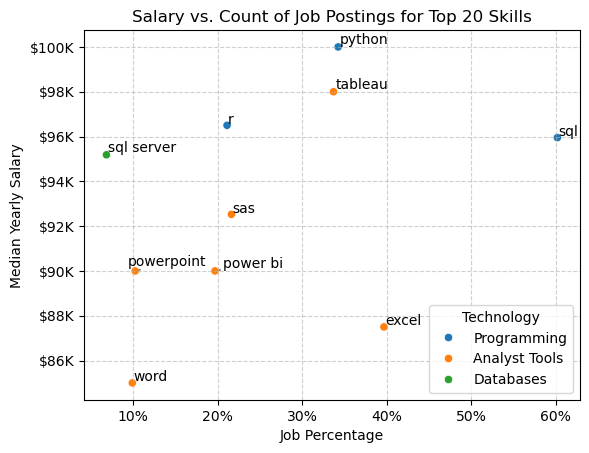

In [87]:
from adjustText import adjust_text

sns.scatterplot(
    data=plot_df, 
    x="skill_percentage", 
    y="median_salary",
    hue="technology" # column from the dataframe
)

plt.ylabel("Median Yearly Salary")
plt.xlabel("Job Percentage")
plt.title("Salary vs. Count of Job Postings for Top 20 Skills")
plt.grid(True, alpha=0.6, linestyle="--")
plt.legend(title="Technology")

texts = []
for i, skill in enumerate(plot_df["skills"]):
    texts.append(plt.text(x=plot_df["skill_percentage"].iloc[i], y=plot_df["median_salary"].iloc[i], s=skill))
adjust_text(texts, arrowprops=dict(arrowstyle="->", color="gray", lw=1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"${int(y / 1000)}K"))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{int(x)}%"))

plt.show()